---
title: "Taller - Sesion 5 - Series de Tiempo y Python IIE - UNAM"
author:
  - name: Luis E. Ascencio G. 
    orcid: 0009-0009-1694-5993
    email: luis.ascencio@cimat.mx
    affiliation: 
      - name: CIMAT
        city: Guanajuato
        state: Guanajuato
        url: https://www.cimat.mx
abstract: > 
  Este Notebook incluye una introduccion al manejo de Series de Tiempo con Python 
keywords:
  - Series de Tiempo
  - ARIMA
  - Python
  - R
  - Estadistica
license: "CC BY"
copyright: 
  holder: Luis E. Ascencio G.
  year: 2025
citation: 
  container-title: CIMAT
  volume: 1
  issue: 1
  doi: 000000/00000000
funding: "This work was supported by the Mexican Secretariat of Science, Humanities, Technology, and Innovation (SECIHTI, México) project CBF2023-2024-3976. Luis Enrique Ascencio Gorozpe is a doctoral student from the PhD in Probability and Statistics program, at Mathematics research center (CIMAT), he received  fellowship with number (CVU) 695305 from SECIHTI."
format:
  pdf:
    documentclass: scrartcl
    toc: true
    number-sections: true
    colorlinks: true
---

In [38]:
import numpy as np
import pandas as pd
from pandas import read_excel # funcion para leer archivos de excel
from io import StringIO
import contextlib
import re
import matplotlib.pyplot as plt

# statsmodels
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose


import pmdarima as pm
from pmdarima import ARIMA
from pmdarima import auto_arima

import sktime
from sktime import datasets
from sktime.utils import plot_series

import warnings
warnings.filterwarnings("ignore")

import session_info

In [3]:
#!pip install xlrd
#!pip install sktime
#!pip install seaborn

In [4]:
h=30

In [5]:
df = pd.read_csv('AirPassengers.csv')
df1 = read_excel('ClayBricks.xls')
df2 = read_excel('Electricity.xls')
df3 = read_excel('MilkProduction.xls')
df4 = read_excel('JapaneseCars.xls')
df5 = read_excel('HouseSales.xls')

# Serie 1

In [6]:
dates=pd.to_datetime(df["Month"])
ts=pd.Series(np.array(df["#Passengers"]),index=dates)

In [7]:
ts

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Length: 144, dtype: int64

In [8]:
from pmdarima.datasets import load_wineind

# this is a dataset from R
wineind = load_wineind().astype(np.float64)

In [9]:
len(wineind)

176

In [10]:
stepwise_fit = pm.auto_arima(wineind, start_p=1, start_q=1,
                              max_p=3, max_q=3, m=12, start_P=0, 
                              seasonal=True,
                              d=1, D=1, trace=True,
                              error_action='ignore',  # don't want to know if an order does not work
                              suppress_warnings=True,  # don't want convergence warnings
                              stepwise=True)  # set to stepwise

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=3066.492, Time=0.26 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=3131.408, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=3097.884, Time=0.07 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=3066.329, Time=0.08 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=3089.456, Time=0.03 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=3067.457, Time=0.14 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=3067.481, Time=0.22 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=3071.631, Time=0.08 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=1.44 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=3117.921, Time=0.14 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=3065.533, Time=0.10 sec
 ARIMA(0,1,2)(0,1,0)[12]             : AIC=3087.883, Time=0.04 sec
 ARIMA(0,1,2)(1,1,1)[12]             : AIC=3066.239, Time=0.19 sec
 ARIMA(0,1,2)(0,1,2)[12]             : AIC=3066.373, Time=0.35 sec
 ARIMA(0,1,2)(1,1,0)[12]

In [11]:
df_fit = pm.auto_arima(ts, start_p=1, start_q=1,
                              max_p=3, max_q=3, m=12, start_P=0, 
                              seasonal=True,
                              d=1, D=1, trace=True,
                              error_action='ignore',  # don't want to know if an order does not work
                              suppress_warnings=True,  # don't want convergence warnings
                              stepwise=True)  # set to stepwise

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1022.896, Time=0.15 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.06 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.08 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.03 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.17 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.22 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.19 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.21 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.34 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.33 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.20 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.07 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.10 sec
 ARIMA(0,1,1)(1,1,1)[12]     

In [12]:
df_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Sat, 08 Nov 2025   AIC                           1019.178
Time:                                     05:24:00   BIC                           1030.679
Sample:                                 01-01-1949   HQIC                          1023.851
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      0.090     -1.372      0.170      -0.301       0.053
ar.S.L24       0.1911      0.107      1.783      0.075      -0.019       0.401
sigma2       130.4480     15.527      8.402      0.000     100.016     160.880
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 4.59
Prob(Q):                              0.92   Prob(JB):                         0.10
Heteroskedasticity (H):               2.70   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
ts_pre=df_fit.predict(h)

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

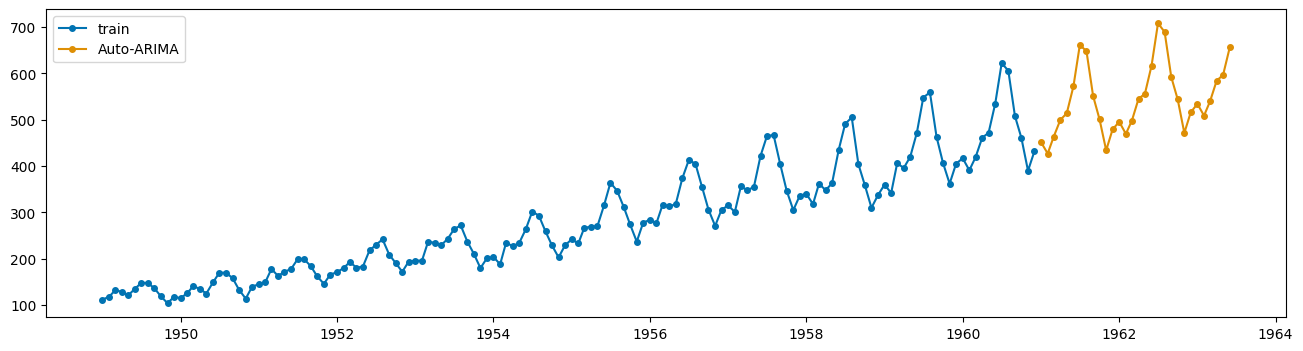

In [14]:
plot_series(ts,ts_pre,labels=["train","Auto-ARIMA"])

# Serie 2

In [15]:
dates1=pd.to_datetime(df1["Dates"])
ts1=pd.Series(np.array(df1["Bricks"]),index=dates1)

In [16]:
ts1

Dates
1956-03-01    189
1956-04-01    204
1956-05-01    208
1956-06-01    197
1956-07-01    187
             ... 
1968-09-01    476
1968-10-01    443
1968-11-01    421
1968-12-01    472
1969-01-01    494
Length: 155, dtype: int64

In [17]:
df1_fit = pm.auto_arima(ts1, start_p=1, start_q=1,
                              max_p=4, max_q=4, m=12, start_P=0, 
                              seasonal=True,
                              d=1, D=1, trace=True,
                              error_action='ignore',  # don't want to know if an order does not work
                              suppress_warnings=True,  # don't want convergence warnings
                              stepwise=True)  # set to stepwise

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1323.673, Time=0.32 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1366.878, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1336.158, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1320.197, Time=0.15 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1365.182, Time=0.04 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1321.846, Time=0.30 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1321.857, Time=0.45 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1337.557, Time=0.08 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=1.69 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1320.760, Time=0.08 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=1321.569, Time=0.20 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=1319.848, Time=0.12 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1364.159, Time=0.02 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1321.518, Time=0.20 sec
 ARIMA(1,1,0)(0,1,2)[12]

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

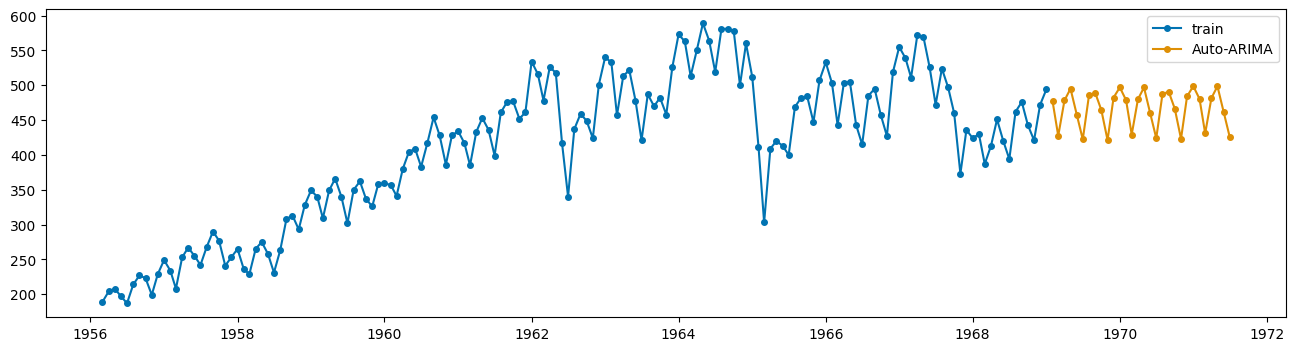

In [18]:
ts1_pre=df1_fit.predict(h)
plot_series(ts1,ts1_pre,labels=["train","Auto-ARIMA"])

# Serie 3

In [19]:
dates2=pd.to_datetime(df2["Month and year"])
ts2=pd.Series(np.array(df2["Kwh"]),index=dates2)

In [20]:
ts2

Month and year
1956-01-01     1254
1956-02-01     1290
1956-03-01     1379
1956-04-01     1346
1956-05-01     1535
              ...  
1995-04-01    13032
1995-05-01    14268
1995-06-01    14473
1995-07-01    15359
1995-08-01    14457
Length: 476, dtype: int64

In [21]:
df2_fit = pm.auto_arima(ts2, start_p=1, start_q=1,
                              max_p=4, max_q=4, m=12, start_P=0, 
                              seasonal=True,
                              d=1, D=1, trace=True,
                              error_action='ignore',  # don't want to know if an order does not work
                              suppress_warnings=True,  # don't want convergence warnings
                              stepwise=True)  # set to stepwise

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=6065.732, Time=0.56 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=6401.709, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=6188.054, Time=0.19 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=6064.304, Time=0.41 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=6221.772, Time=0.08 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=6064.317, Time=0.55 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=6063.199, Time=1.87 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=6050.038, Time=5.17 sec
 ARIMA(0,1,1)(2,1,2)[12]             : AIC=6051.909, Time=5.06 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=6058.186, Time=1.21 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=6226.586, Time=1.12 sec
 ARIMA(1,1,1)(1,1,2)[12]             : AIC=6058.202, Time=6.80 sec
 ARIMA(0,1,2)(1,1,2)[12]             : AIC=6055.825, Time=5.88 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=inf, Time=3.59 sec
 ARIMA(1,1,2)(1,1,2)[12]

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

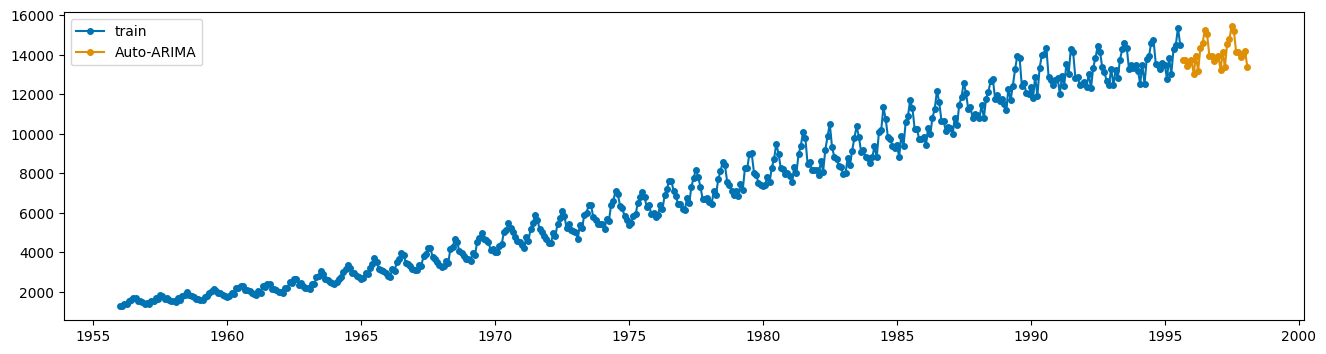

In [22]:
ts2_pre=df2_fit.predict(h)
plot_series(ts2,ts2_pre,labels=["train","Auto-ARIMA"])

# Serie 4

In [23]:
df3

,Monthly Milk Production per Cow
0,589
1,561
2,640
3,656
4,727
...,...
163,858
164,817
165,827
166,797


In [24]:
#dates3=pd.to_datetime(df3["Monthly Milk Production per Cow"])
ts3=pd.Series(np.array(df3["Monthly Milk Production per Cow"]))

In [25]:
df3_fit = pm.auto_arima(ts3, start_p=1, start_q=1,
                              max_p=4, max_q=4, m=12, start_P=0, 
                              seasonal=True,
                              d=1, D=1, trace=True,
                              error_action='ignore',  # don't want to know if an order does not work
                              suppress_warnings=True,  # don't want convergence warnings
                              stepwise=True)  # set to stepwise

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1068.064, Time=0.14 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1119.969, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1081.584, Time=0.05 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1066.296, Time=0.10 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1114.995, Time=0.02 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1068.030, Time=0.15 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1067.976, Time=0.39 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1082.123, Time=0.07 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=1.21 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1072.280, Time=0.07 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=1067.796, Time=0.13 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=1066.207, Time=0.10 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1114.845, Time=0.02 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1067.913, Time=0.14 sec
 ARIMA(1,1,0)(0,1,2)[12]

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

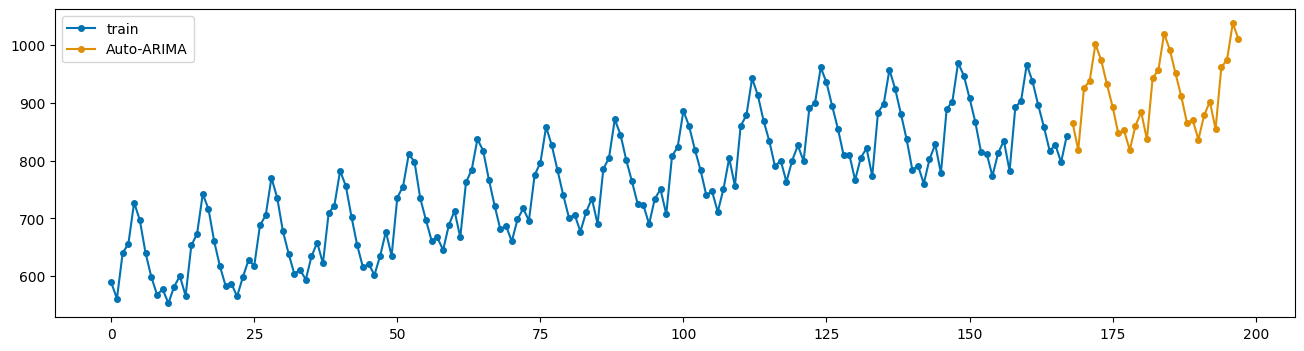

In [26]:
ts3_pre=df3_fit.predict(h)
plot_series(ts3,ts3_pre,labels=["train","Auto-ARIMA"])

# Serie 5

In [27]:
df4

,Mileage,Price
0,19,14.944
1,19,14.799
2,20,24.760
3,20,14.929
4,20,13.949
5,21,17.879
6,21,11.650
7,21,23.300
8,22,17.899
9,23,21.498


In [28]:
dates4=pd.to_numeric(df4["Mileage"])
ts4=pd.Series(np.array(df4["Price"]),index=dates4)

In [29]:
ts4

Mileage
19    14.944
19    14.799
20    24.760
20    14.929
20    13.949
21    17.879
21    11.650
21    23.300
22    17.899
23    21.498
24    13.249
25     9.599
25    10.989
27    13.945
28    13.071
32     6.599
33     9.410
34     5.866
35     6.488
dtype: float64

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

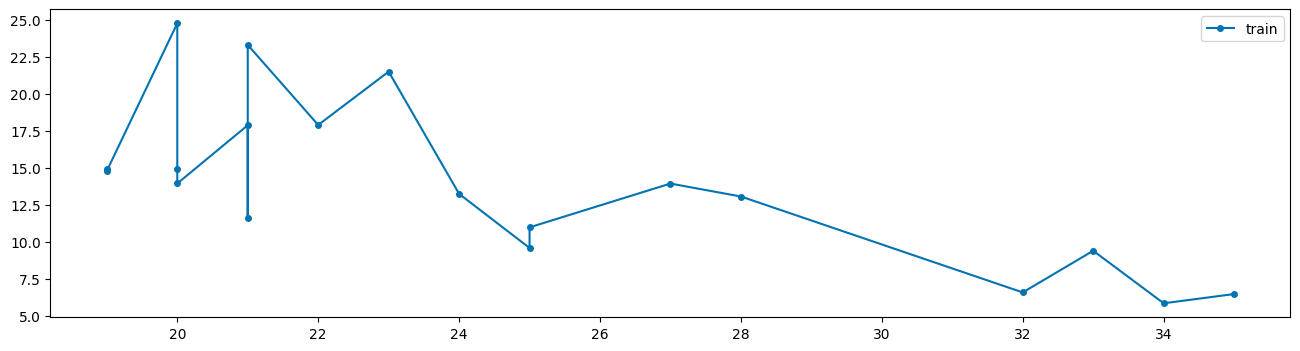

In [30]:
plot_series(ts4,labels=["train"])

# Serie 6

In [31]:
df5

,Month,HouseSales
0,1956-01-01,55
1,1956-02-01,60
2,1956-03-01,68
3,1956-04-01,63
4,1956-05-01,65
...,...,...
270,1978-07-01,64
271,1978-08-01,63
272,1978-09-01,55
273,1978-10-01,54


In [32]:
dates5=pd.to_datetime(df5["Month"])
ts5=pd.Series(np.array(df5["HouseSales"]),index=dates5)

In [33]:
df5_fit = pm.auto_arima(ts5, start_p=1, start_q=1,
                              max_p=4, max_q=4, m=12, start_P=0, 
                              seasonal=True,
                              d=1, D=1, trace=True,
                              error_action='ignore',  # don't want to know if an order does not work
                              suppress_warnings=True,  # don't want convergence warnings
                              stepwise=True)  # set to stepwise

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=0.73 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1690.202, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1633.997, Time=0.07 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.40 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1689.378, Time=0.03 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1619.080, Time=0.26 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.49 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.73 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1618.152, Time=0.32 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=1634.148, Time=0.07 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=1.25 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=0.35 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1618.780, Time=0.30 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1615.016, Time=0.60 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=1628.6

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

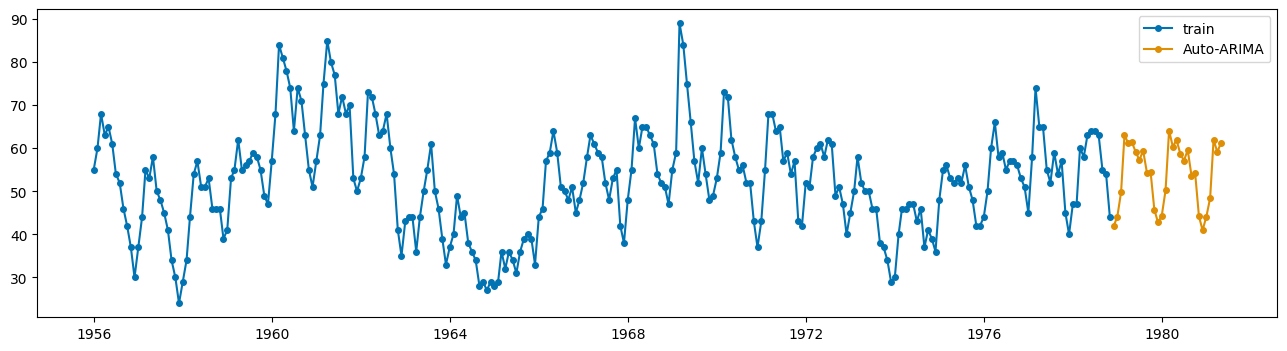

In [34]:
ts5_pre=df5_fit.predict(h)
plot_series(ts5,ts5_pre,labels=["train","Auto-ARIMA"])

In [39]:
session_info.show(html=False)

-----
matplotlib          3.9.4
numpy               2.0.2
pandas              2.3.1
pmdarima            2.0.4
session_info        v1.0.1
sktime              0.38.5
statsmodels         0.14.5
-----
IPython             8.18.1
jupyter_client      8.6.3
jupyter_core        5.8.1
-----
Python 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) [GCC 13.3.0]
Linux-6.8.0-87-generic-x86_64-with-glibc2.39
-----
Session information updated at 2025-11-08 05:26
